<a href="https://colab.research.google.com/github/Brigiuli/People-Analytics/blob/main/People-Analytics/employee_attrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 📋 **Información del Proyecto**

**- Resumen/Contexto:**

La rotación de empleados es un problema importante para las empresas debido a los costos de contratación y capacitación.

**- Objetivo:**

El objetivo de este proyecto es analizar y predecir si un empleado abandonará la empresa (1) o no (0).

**- Datos**

El dataset utilizado proviene de Kaggle y contiene información de empleados.

**- Modelos:**

Se utilizarán modelos de Machine Learning como Regresión Logística y Random Forest.

##**1. Importación de datos**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [3]:
#conectar al drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#cargar la data
df = pd.read_csv("/content/drive/MyDrive/HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 2. Exploración de datos (EDA)

In [5]:
#Explorando los datos
df.info()
df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


##3. Limpieza y tratamiento

In [19]:
df["Attrition"].value_counts()

,count
Attrition,
0,1233
1,237


In [6]:
df.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [7]:
#evaluando cuál de las variables son irrelevantes
df.nunique()

,0
Age,43
Attrition,2
BusinessTravel,3
DailyRate,886
Department,3
DistanceFromHome,29
Education,5
EducationField,6
EmployeeCount,1
EmployeeNumber,1470


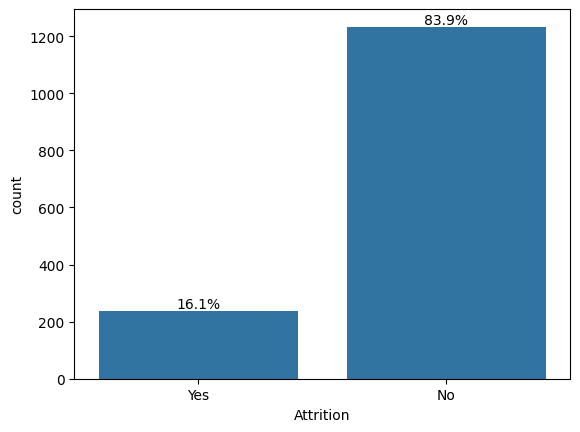

In [ ]:
#ver balance de datos
ax = sns.countplot(x='Attrition', data=df)

total = len(df)

for p in ax.patches:
    ax.annotate(f'{100*p.get_height()/total:.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.show()


<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

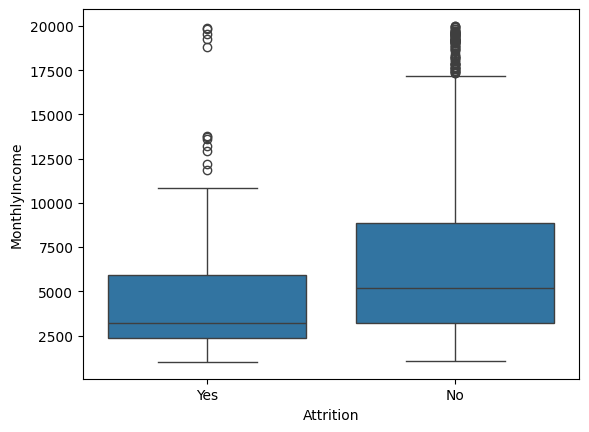

In [ ]:
#explorando insights
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)


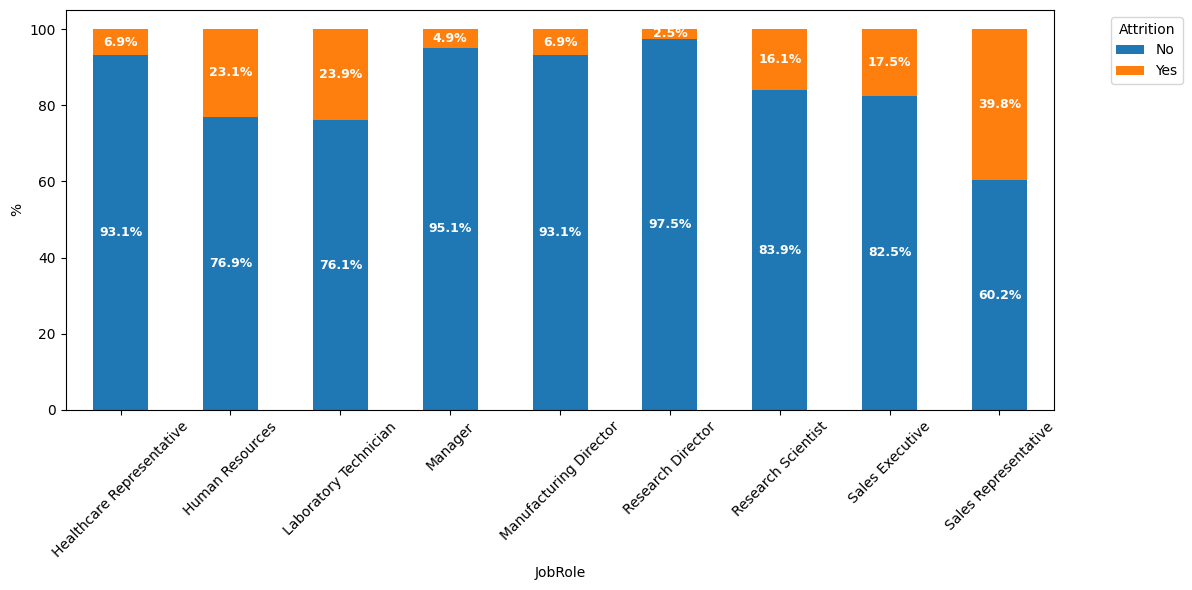

In [ ]:
tabla = pd.crosstab(df['JobRole'], df['Attrition'], normalize='index') * 100
ax = tabla.plot(kind='bar', stacked=True, figsize=(12,6))

for container in ax.containers:
    ax.bar_label(container,fmt='%.1f%%',label_type='center',color='white',fontsize=9,fontweight='bold')

ax.legend(title='Attrition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.ylabel('%')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

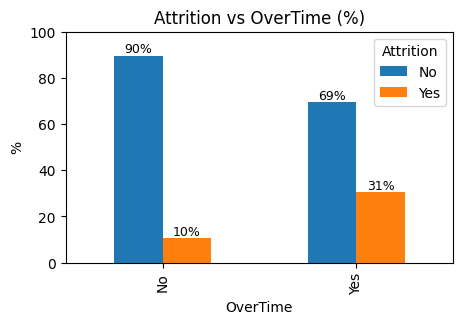

In [ ]:
# % por grupo
df_pct = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100

# gráfico
ax = df_pct.plot(kind='bar', figsize=(5,3))

# etiquetas dentro de barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)

plt.title('Attrition vs OverTime (%)')
plt.ylabel('%')
plt.xlabel('OverTime')
plt.legend(title='Attrition')
plt.ylim(0,100)

plt.show()

##4. Feature engineering

In [8]:
#limpiar columnas irrelevantes
df = df.drop(['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'], axis=1)

In [9]:
#Limpiar texto
df['Attrition'] = df['Attrition'].str.strip().str.capitalize()

In [10]:
#convirtiendo la variable objetivo (target) a números
df['Attrition'] = df['Attrition'].map({'Yes':1, 'No':0})

In [11]:
df['Attrition'].isna().sum()

np.int64(0)

In [12]:
#enconding convirtiendo las variables categóricas a números
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [13]:
#separando las variables
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [ ]:
y.isna().sum() #validación final

np.int64(0)

In [14]:
#split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
#escalado
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)  # aprende SOLO de train
X_test = scaler.transform(X_test)        # aplica a test

##5. Modelado (Logistic Regression, Random Forest)

In [16]:
#Modelo 1: Regresión logística
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

In [17]:
#modelo random forest
model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

In [21]:
print("Logistic Regression")
print(accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

print("Random Forest")
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Logistic Regression
0.8945578231292517
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       255
           1       0.70      0.36      0.47        39

    accuracy                           0.89       294
   macro avg       0.80      0.67      0.71       294
weighted avg       0.88      0.89      0.88       294

Random Forest
0.8775510204081632
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       255
           1       0.80      0.10      0.18        39

    accuracy                           0.88       294
   macro avg       0.84      0.55      0.56       294
weighted avg       0.87      0.88      0.83       294



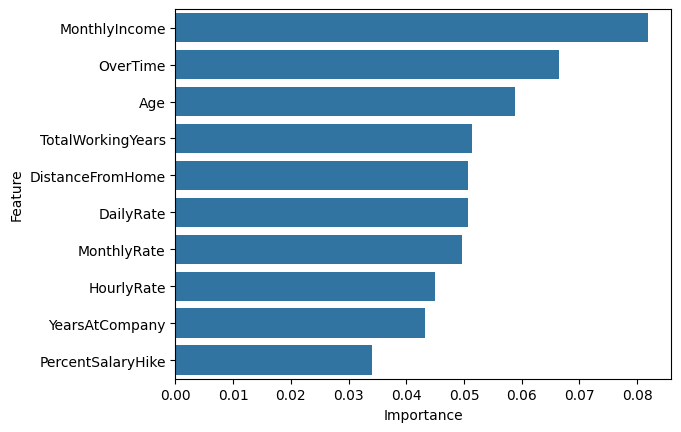

In [22]:
#evaluando la importancia de las variables
importances = model_rf.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feat_imp.head(10))
plt.show()

BALANCEO DE DATOS (SMOTE)

In [23]:
!pip install imbalanced-learn

In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

In [25]:
print(y_train.value_counts())
print(pd.Series(y_resampled).value_counts())

Attrition
0    978
1    198
Name: count, dtype: int64
Attrition
0    978
1    978
Name: count, dtype: int64


In [26]:
#REENTRENAR MODELO (MEJORADO)
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_resampled, y_resampled)

y_pred = model_lr.predict(X_test)

In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7482993197278912
              precision    recall  f1-score   support

           0       0.93      0.77      0.84       255
           1       0.29      0.62      0.39        39

    accuracy                           0.75       294
   macro avg       0.61      0.69      0.62       294
weighted avg       0.84      0.75      0.78       294



AJUSTE DE THRESHOLD

In [28]:
y_proba = model_lr.predict_proba(X_test)[:,1]

In [29]:
#cambiamos umbral a 0.3
y_pred_custom = (y_proba > 0.3).astype(int)

In [30]:
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.93      0.59      0.72       255
           1       0.21      0.72      0.33        39

    accuracy                           0.61       294
   macro avg       0.57      0.66      0.53       294
weighted avg       0.84      0.61      0.67       294



In [33]:
#Probando múltiples threshold para evaluar métricas
from sklearn.metrics import f1_score, recall_score, precision_score

thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred = (y_proba > t).astype(int)

    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append((t, recall, precision, f1))

In [34]:
df_results = pd.DataFrame(results, columns=['threshold','recall','precision','f1'])
df_results.sort_values(by='f1', ascending=False)

,threshold,recall,precision,f1
13,0.75,0.461538,0.500000,0.480000
11,0.65,0.538462,0.428571,0.477273
10,0.60,0.589744,0.370968,0.455446
12,0.70,0.461538,0.439024,0.450000
9,0.55,0.615385,0.347826,0.444444
14,0.80,0.358974,0.518519,0.424242
7,0.45,0.666667,0.285714,0.400000
8,0.50,0.615385,0.289157,0.393443
15,0.85,0.282051,0.611111,0.385965
6,0.40,0.666667,0.254902,0.368794


A continuación, se presenta la matriz de confusión del modelo final, la cual permite visualizar los aciertos y errores en la clasificación de empleados en riesgo.

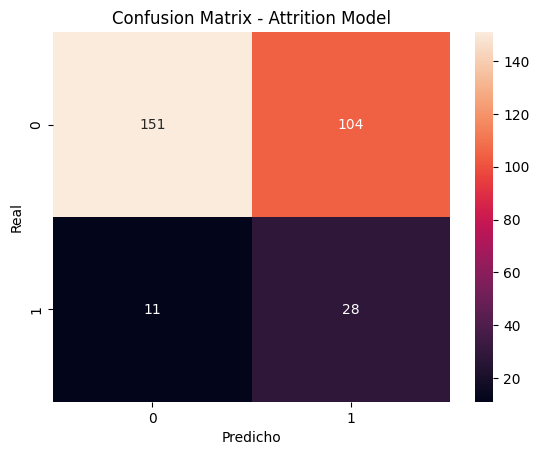

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_custom)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Confusion Matrix - Attrition Model")
plt.show()

**Conclusiones:**

- Se mejoró el modelo, ya que está sesgado hacia la clase mayoritaria, para ello se aplicó SMOTE para corregir el desbalance de clases, mejorando la capacidad del modelo para identificar empleados en riesgo de rotación. Adicionalmente, se ajustó el threshold de decisión para priorizar el recall sobre la precisión, en línea con los objetivos de retención en RRHH.


- En cuanto a la importancia de las variables podemos ver a simple vista que el "ingreso mensual" y las "horas extras" son las más influyentes en el modelo. Por útlimo la variable que menos aporta es la "Numcompaniesworked".

- El ajuste del threshold permitió incrementar el recall (capacidad de detectar empleados que realmente abandonan la empresa) hasta un 72% al utilizar un valor de 0.3, priorizando la detección de empleados en riesgo de rotación. Sin embargo, esto generó una disminución significativa en la precisión, incrementando los falsos positivos.

Adicionalmente, el uso de SMOTE contribuyó a mejorar el desempeño del modelo al equilibrar las clases durante el entrenamiento.

Posteriormente, se evaluaron múltiples thresholds, identificando un trade-off entre recall y precision. Como resultado, desde una perspectiva de negocio, se recomienda un threshold cercano a 0.6, ya que permite equilibrar la detección de empleados en riesgo con el control de costos operativos, haciendo el modelo más viable en un entorno real.


**Insights:**

- Se observa que los empleados con menor ingreso mensual presentan una mayor probabilidad de rotación, lo que sugiere que la compensación salarial es un factor relevante en la retención.

- La rotación es similar entre empleados con y sin horas extra; sin embargo, se identifica una ligera mayor tendencia en aquellos con overtime, lo que podría indicar un impacto parcial del estrés laboral.

- En general, el overtime no explica completamente la rotación, pero puede considerarse un factor secundario asociado al desgaste del empleado.